# Avaliação da extração por LLM 

Este notebook apresenta os códigos utilizados para as análises e avaliação da extração por LLM. O código foi contruído com auxílio do GPT-5.6 Luna.

In [1]:
import pandas as pd 
import ast
from Scripts.schema import (
    SynthesisMethod,
    SynthesisDirection,
    PostSynthesisModification,
    SynthesisEngineering,
    NumSheets,
    StructureFormat,
    SpecificApplication,
    GeneralApplication,
)
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

## $\bullet$ Acessando os dados 

Vamos acessar os dados e selecionar os resumos aleatórios para extração manual

In [5]:
# --- Carregando os resumos base --- #
df_brutos = pd.read_excel("raw_data/raw_abstracts.xlsx")

# --- Carregando o dataset extraído --- #
df_extracao_avaliacao = pd.read_csv("resultados/extracted_data_analysis.xlsx")
df_extracao = pd.read_csv("resultados/extracted_data.xls")

print("Dados Extraídos:")
print(len(df_extracao))
display(df_extracao.tail(5))

Dados Extraídos:
1927


,Unnamed: 0,doc_id,synthesis_methods,synthesis_direction,post_synthesis_modifications,synthesis_engineering,num_sheets,structure_format,specific_applications,general_applications
1922,1922,"Panghal, A; Sahoo, D; Deepak, D; Deshmukh, S; ...",['hydrothermal'],NaN,NaN,NaN,NaN,"['nanoparticle', 'nanoparticle']",NaN,NaN
1923,1923,"Samarasinghe, LV; Muthukumaran, S; Baskaran, K","['ball_milling', 'liquid_phase_exfoliation']",NaN,NaN,NaN,NaN,['nanoflower'],['pollutants'],['photocatalysis']
1924,1924,"Chen, GP; Ding, N; Li, F; Fan, YZ; Luo, YH; Li...","['hydrothermal', 'intercalation_exfoliation', ...",NaN,NaN,NaN,NaN,"['nanoflower', 'nanoparticle']",['HER'],['photocatalysis']
1925,1925,"Johari, MH; Sirat, MS; Mohamed, MA; Nasir, SNF...",['chemical_vapor_deposition'],NaN,NaN,NaN,NaN,['nanoflake'],['HER'],['electrocatalysis']
1926,1926,"Fu, WJ; Zhao, YH; Wang, HW; Chen, X; Liu, KF; ...","['autoclave_method', 'hydrothermal']",NaN,NaN,NaN,NaN,['nanoflower'],['HER'],['electrocatalysis']


### Selecionando resumos aleatórios

In [6]:
# --- Amostrando 30 resumos aleatórios --- 
selecionados = df_extracao_avaliacao.sample(n=30, random_state=639)
ids_selecionados = [(index, artigo["doc_id"]) for (index, artigo) in selecionados.iterrows()]

display(df_extracao_avaliacao.iloc[list(map(lambda x: x[0], ids_selecionados))])

,Unnamed: 0,doc_id,synthesis_methods,synthesis_direction,post_synthesis_modifications,synthesis_engineering,num_sheets,structure_format,specific_applications,general_applications
1275,1275,"Jiang, Y; Li, JB; Wang, Q; Qi, ZT; Yao, XM; Wa...",['hydrothermal'],NaN,NaN,NaN,['few_layer'],['quantum_dot'],NaN,['photocatalysis']
484,484,"Zhao, Y; Zheng, LH; Han, SY; Xu, B; Fang, ZY; ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
381,381,"Wu, LZ; Zhang, L; Liu, RX; Ge, HY; Tao, ZW; Me...",['liquid_phase_exfoliation'],NaN,NaN,NaN,NaN,['nanoflake'],['pollutants'],['photocatalysis']
1183,1183,"Shi, HY; Zhang, YY; Pang, N; Xu, SH; Xiong, DY...",NaN,NaN,NaN,NaN,NaN,NaN,"['HER', 'OER']",NaN
470,470,"Zhang, JZ; Zhang, J; Liu, KL; Yang, T; Tian, J...",NaN,NaN,NaN,"['defect_engineering', 'defect_engineering', '...",NaN,"['nanoparticle', 'nanoparticle', 'nanoparticle']","['pollutants', 'pollutants', 'pollutants']","['electrocatalysis', 'electrocatalysis', 'elec..."
825,825,"Xia, TY; Zhou, L; Gu, SQ; Gao, H; Ren, XY; Li,...",NaN,NaN,NaN,['defect_engineering'],NaN,"['nanoflake', 'nanoflake', 'nanoflake']",['HER'],['electrocatalysis']
1221,1221,"Han, DL; Ma, MX; Han, YJ; Cui, ZD; Liang, YQ; ...",NaN,NaN,"['molybdenum_vacancy', 'molybdenum_vacancy']",NaN,NaN,"['nanotube', 'nanotube']",['HER'],['electrocatalysis']
85,85,"Peng, K; Fu, LJ; Yang, HM; Ouyang, J; Tang, AD","['intercalation_exfoliation', 'hydrothermal']",NaN,NaN,NaN,NaN,['nanoflower'],['HER'],['electrocatalysis']
969,969,"Sopha, H; Tesfaye, AT; Zazpe, R; Michalicka, J...","['thermal_synthesis', 'thermal_synthesis']",NaN,NaN,NaN,NaN,"['nanotube', 'nanotube']",NaN,NaN
513,513,"Wang, XY; Liu, YF; Khalil, MI; Wang, GW; Zhang...",NaN,NaN,NaN,NaN,NaN,['ribbon'],['HER'],['electrocatalysis']


In [7]:
autores = df_extracao_avaliacao.iloc[list(map(lambda x: x[0], ids_selecionados))]["doc_id"].to_list()
 
abstracts_inteiros = []
 
for authors in autores:
    abstracts_inteiros.append(
        (
            df_brutos[df_brutos["Authors"] == authors]["Authors"].to_list()[0],
            df_brutos[df_brutos["Authors"] == authors]["Abstract"].to_list()[0]
        )
    )

print(len(autores))

print(abstracts_inteiros[29])

30
('Zheng, XZ; Han, HJ; Liu, JF; Yang, Y; Pan, LL; Zhang, SJ; Meng, SG; Chen, SF', 'Defect engineering is considered as an efficient method for improving the photocatalytic activity of semiconductor photocatalysis because defects can not only serve as trapping centers for electrons and holes but also work as active sites for reaction. Herein, we synthesized a series of MoS2/CdS heterojunctions with abundant sulfur vacancies and used for photocatalytic N-2 reduction. The sulfur vacancies at MoS2/CdS heterojunctions were confirmed by UV-vis diffuse-reflectance spectroscopy (UVDRS) and electron paramagnetic resonance. The charge transfer behaviors of the photocatalysts were characterized by X-ray photoelectron spectroscopy, transient photocurrent, steady and transient photoluminescence spectroscopy, and so forth. Under visible light irradiation for 4 h, the production of NH3 at 3% Mo-2/CdS heterojunctions (249.7 mg L-1 g(-1)) was about 5.4 and 3.9 times higher than that of pure MoS 2 (45

### Carregando as extrações manuais

In [9]:
# --- Definindo as colunas de interesse --- #

colunas = ["synthesis_methods","synthesis_direction","post_synthesis_modifications",
           "synthesis_engineering","num_sheets","structure_format",
           "specific_applications","general_applications"]

# --- Carregando os dados extraídos manualmente ---

df_referencia_r = pd.read_excel("resultados/manual_extractions.xlsx")

display(df_referencia_r.head(10))

,doc_id,synthesis_methods,synthesis_direction,post_synthesis_modifications,synthesis_engineering,num_sheets,structure_format,specific_applications,general_applications
0,"Jiang, Y; Li, JB; Wang, Q; Qi, ZT; Yao, XM; Wa...","[""hydrothermal""]","[""bottom_up""]",NaN,NaN,"[""few_layer""]","[""quantum_dot""]",NaN,"[""photocatalysis""]"
1,"Zhao, Y; Zheng, LH; Han, SY; Xu, B; Fang, ZY; ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Wu, LZ; Zhang, L; Liu, RX; Ge, HY; Tao, ZW; Me...","[""liquid_phase_exfoliation""]",NaN,"[""phase_adjustment"", ""heterojunction""]",NaN,NaN,NaN,"[""pollutants""]","[""photocatalysis""]"
3,"Shi, HY; Zhang, YY; Pang, N; Xu, SH; Xiong, DY...",NaN,NaN,"[""support"", ""heteroatom_doping""]",NaN,NaN,NaN,"[""HER"", ""OER""]","[""electrocatalysis""]"
4,"Zhang, JZ; Zhang, J; Liu, KL; Yang, T; Tian, J...",NaN,NaN,"[""heterojunction"",""sulfur_vacancy"", ""support""]",NaN,NaN,NaN,NaN,"[""electrocatalysis""]"
5,"Xia, TY; Zhou, L; Gu, SQ; Gao, H; Ren, XY; Li,...",NaN,NaN,"[""heterojunction"", ""support""]","[""defect_engineering""]",NaN,NaN,NaN,"[""electrocatalysis""]"
6,"Han, DL; Ma, MX; Han, YJ; Cui, ZD; Liang, YQ; ...",NaN,NaN,"[""heterojunction""]",NaN,NaN,"[""nanoflake""]",NaN,"[""photocatalysis""]"
7,"Peng, K; Fu, LJ; Yang, HM; Ouyang, J; Tang, AD","[""hydrothermal""]",NaN,"[""heterojunction""]",NaN,NaN,"[""nanoflake""]","[""pollutants""]",NaN
8,"Sopha, H; Tesfaye, AT; Zazpe, R; Michalicka, J...","[""chemical_vapor_deposition""]",NaN,"[""support""]",NaN,"[""few_layer""]","[""nanoflake""]",NaN,NaN
9,"Wang, XY; Liu, YF; Khalil, MI; Wang, GW; Zhang...",NaN,NaN,NaN,NaN,NaN,NaN,"[""OER"", ""pollutants""]","[""electrocatalysis""]"


## $\bullet$ Calculando o F1 score para cada coluna 

Vamos utilizar o MultiLabelBinarizer e o f1_score do sklearn para calcular o F1 Score para feature considerando os 30 resumos selecionados aleatoriamente e suas extrações manuais, vamos também transformar todos itens em listas, tratando NaNs como listas vazias. 

In [17]:
# --- Funções de Apoio --- #

def to_list(value):
    """Garante que o valor seja uma lista, tratando os formatos mais comuns
    que aparecem no pipeline: já é lista, é None/NaN, é string de lista
    Python ("['a', 'b']"), ou é uma string solta com um item só ("a")."""

    # já é lista — nada a fazer
    if isinstance(value, list):
        return value

    # None ou NaN (pandas) — vira lista vazia
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []

    # string vazia — vira lista vazia
    if isinstance(value, str) and value.strip() == "":
        return []

    # string que parece uma lista Python: "['hydrothermal', 'CVD']"
    if isinstance(value, str) and value.strip().startswith("["):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass   # não era de fato uma lista válida — cai no tratamento abaixo

    # string solta com um item só, ou separada por ";" (formato da anotação manual)
    if isinstance(value, str):
        if ";" in value:
            return [item.strip() for item in value.split(";") if item.strip()]
        return [value.strip()]

    # qualquer outro tipo escalar (número, etc.) — vira lista de um item
    return [value]


In [25]:
# --- Ajustando os dataset --- #

df_previsao = selecionados[colunas].map(to_list) #### Funciona!!!
df_referencia = df_referencia_r[colunas].map(to_list)

# --- Calculando o F1 

campos_multilabel = {
    "synthesis_methods": SynthesisMethod,
    "synthesis_direction": SynthesisDirection,
    "post_synthesis_modifications": PostSynthesisModification,
    "synthesis_engineering": SynthesisEngineering,
    "num_sheets": NumSheets,
    "structure_format": StructureFormat,
    "specific_applications": SpecificApplication,
    "general_applications": GeneralApplication,
}

resultados = []

for campo, enum_cls in campos_multilabel.items():
    # Extrai a lista de categorias válidas a partir do Enum
    categories = [e.value for e in enum_cls]
    
    # Inicializa o binarizador com as classes mapeadas do seu Schema
    mlb = MultiLabelBinarizer(classes=categories)

    # Aplica a transformação nas colunas correspondentes de cada DataFrame
    y_true_bin = mlb.fit_transform(df_referencia[campo])
    y_pred_bin = mlb.transform(df_previsao[campo])

    # Calcula as métricas e salva na lista
    resultados.append({
        "campo": campo,
        "f1_micro": f1_score(y_true_bin, y_pred_bin, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true_bin, y_pred_bin, average="macro", zero_division=0),
    })

# Transforma a lista de resultados em um DataFrame para visualização tabular bonita no notebook
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,campo,f1_micro,f1_macro
0,synthesis_methods,0.628571,0.273626
1,synthesis_direction,0.666667,0.333333
2,post_synthesis_modifications,0.090909,0.073950
3,synthesis_engineering,0.222222,0.142857
4,num_sheets,0.727273,0.555556
5,structure_format,0.260870,0.200397
6,specific_applications,0.666667,0.536741
7,general_applications,0.625000,0.633333


In [19]:
x = np.arange(len(df_resultados))
largura = 0.35

def plot_f1_comparison(
    df_resultados,
    figsize=(12, 7),
    font_size=12,
    value_font_size=10
):
    x = np.arange(len(df_resultados))
    largura = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # Barras
    barras_micro = ax.bar(
        x - largura/2,
        df_resultados["f1_micro"],
        largura,
        label="F1-micro",
        edgecolor="black",
        hatch="."
    )

    barras_macro = ax.bar(
        x + largura/2,
        df_resultados["f1_macro"],
        largura,
        label="F1-macro",
        edgecolor="black",
        hatch="///"
    )

    # Valores acima das barras
    for barras in [barras_micro, barras_macro]:
        for barra in barras:
            altura = barra.get_height()

            ax.text(
                barra.get_x() + barra.get_width()/2,
                altura + 0.015,
                f"{altura:.2f}",
                ha="center",
                va="bottom",
                fontsize=value_font_size
            )

    # Eixos
    ax.set_xticks(x)
    ax.set_xticklabels(
        df_resultados["campo"],
        rotation=45,
        ha="right",
        fontsize=font_size
    )

    ax.set_ylabel(
        "F1-score",
        fontsize=font_size
    )

    ax.set_xlabel(
        "Feature",
        fontsize=font_size
    )

    ax.set_title(
        "F1-micro e F1-macro por feature",
        fontsize=font_size + 2
    )

    ax.tick_params(
        axis="y",
        labelsize=font_size
    )

    ax.set_ylim(0, 1.1)

    ax.legend(fontsize=font_size)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    return fig, ax

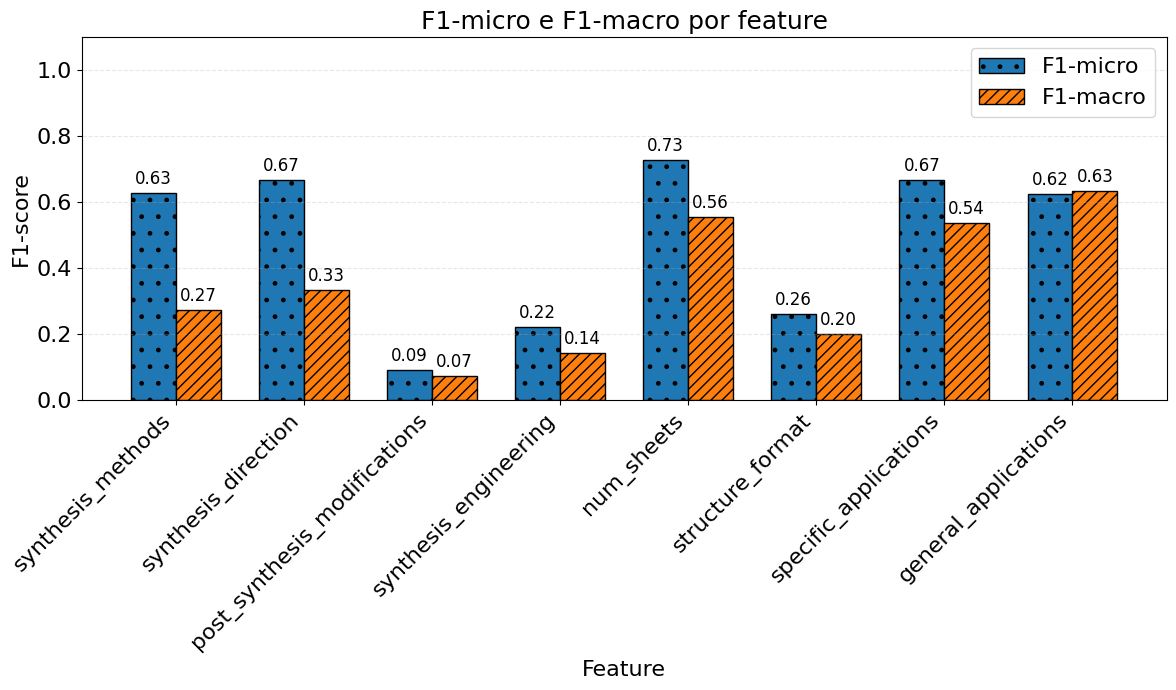

In [264]:
fig, ax = plot_f1_comparison(
    df_resultados,
    figsize=(12, 7),
    font_size=16,
    value_font_size=12
)

fig.savefig(
    "Resultados/f1_comparison.png",
    transparent=True,
    dpi=300
)

plt.show()

## $\bullet$ Analisando a razão de NANs para cada feature 

Vamos fazer as frações de valores faltantes por feature ao longo do dataset completo.

In [20]:
df_features = df_extracao.drop(columns=["doc_id"])
per_category_absence = (
    df_features.iloc[:, 1:]
    .isna()
    .mean()
    .round(2)
    .to_dict()
)

per_category_absence

{'synthesis_methods': 0.41,
 'synthesis_direction': 0.98,
 'post_synthesis_modifications': 0.79,
 'synthesis_engineering': 0.91,
 'num_sheets': 0.88,
 'structure_format': 0.29,
 'specific_applications': 0.11,
 'general_applications': 0.16}

In [21]:
def plot_nan_ratio(
    per_category_absence,
    figsize=(12, 7),
    font_size=12,
    value_font_size=10
):
    features = list(per_category_absence.keys())
    values = list(per_category_absence.values())

    x = np.arange(len(features))

    fig, ax = plt.subplots(figsize=figsize)

    # Padrões alternados entre as barras
    hatches = [".", "///"]

    barras = ax.bar(
        x,
        values,
        edgecolor="black"
    )

    for i, barra in enumerate(barras):
        barra.set_hatch(hatches[i % len(hatches)])

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.015,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=value_font_size
        )

    # Eixo X
    ax.set_xticks(x)
    ax.set_xticklabels(
        features,
        rotation=45,
        ha="right",
        fontsize=font_size
    )

    # Eixo Y
    ax.set_ylabel(
        "Razão de valores ausentes (NaN)",
        fontsize=font_size
    )

    ax.set_xlabel(
        "Feature",
        fontsize=font_size
    )

    ax.set_title(
        "Razão de valores ausentes por feature",
        fontsize=font_size + 2
    )

    ax.tick_params(
        axis="y",
        labelsize=font_size
    )

    # Como é uma razão, o máximo natural é 1
    ax.set_ylim(0, 1.1)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    return fig, ax

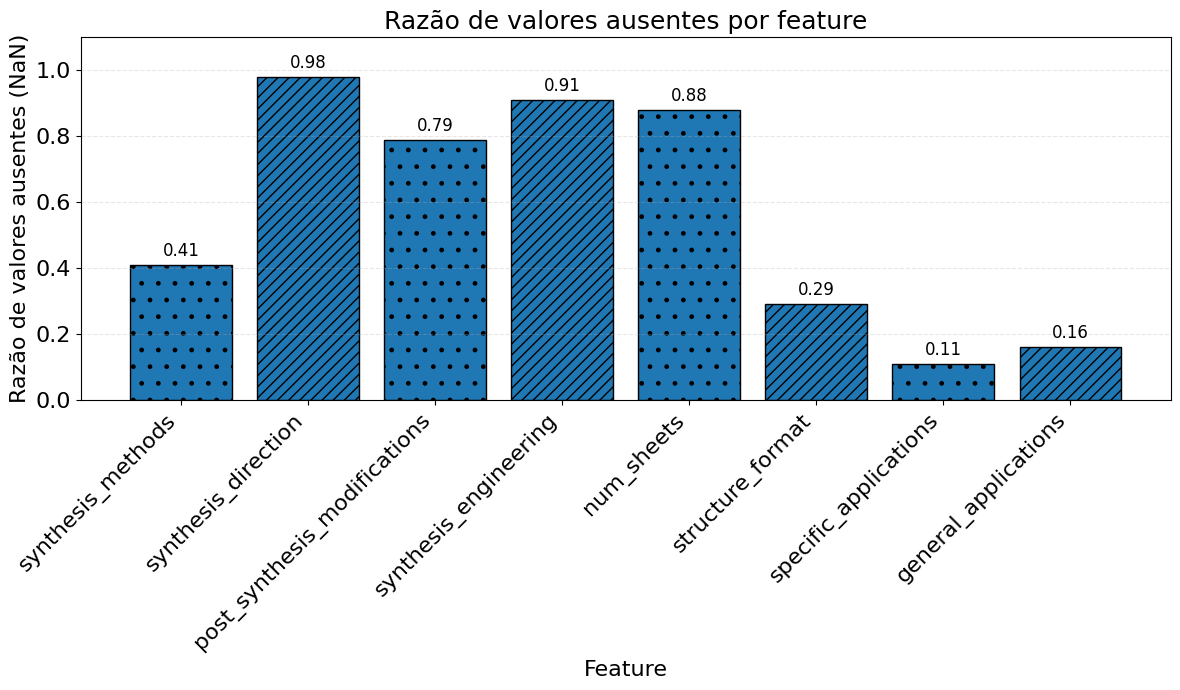

In [30]:
fig, ax = plot_nan_ratio(
    per_category_absence,
    figsize=(12, 7),
    font_size=16,
    value_font_size=12
)

fig.savefig(
    "../Resultados/nan_por_feature.png",
    transparent=True,
    dpi=300
)

plt.show()

{'synthesis_methods': 0.53, 'synthesis_direction': 0.93, 'post_synthesis_modifications': 0.23, 'synthesis_engineering': 0.97, 'num_sheets': 0.77, 'structure_format': 0.47, 'specific_applications': 0.37, 'general_applications': 0.3}


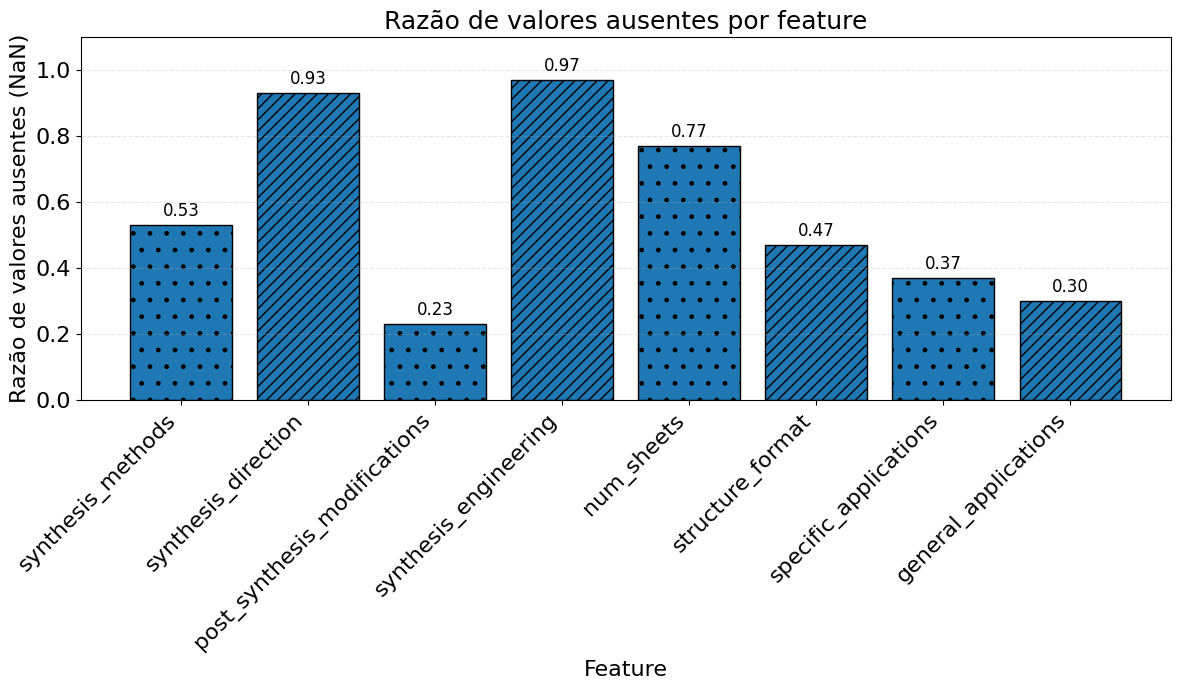

In [31]:
per_category_absence_ref = (
    df_referencia_r.iloc[:, 1:]
    .isna()
    .mean()
    .round(2)
    .to_dict()
)

print(per_category_absence_ref)

fig, ax = plot_nan_ratio(
    per_category_absence_ref,
    figsize=(12, 7),
    font_size=16,
    value_font_size=12
)

fig.savefig(
    "../Resultados/nan_por_feature_ref.png",
    transparent=True,
    dpi=300
)

plt.show()

## $\bullet$ Analisando a frequência de cada label para cada feature

Vamos apresentar qual a proporção entre cada label ao longo do dataset para cada feature.

In [250]:
def plot_label_frequency(df, campo, top_n=5):

    labels = []

    for valor in df[campo].dropna():
        if isinstance(valor, str):
            valor = ast.literal_eval(valor)

        labels.extend(valor)

    # Frequências
    contagem = Counter(labels)

    mais_frequentes = contagem.most_common(top_n)

    labels_top = dict(mais_frequentes)

    outras = sum(
        quantidade
        for label, quantidade in contagem.items()
        if label not in labels_top
    )

    if outras > 0:
        labels_top["Outras"] = outras

    nomes = list(labels_top.keys())
    valores = list(labels_top.values())

    # Padrões
    hatches = [
        ".",
        "*",
        "//",
        "\\\\",
        "xx",
        "oo",
        "--",
        "++",
        "||",
        "..",
    ]

    fig, ax = plt.subplots(figsize=(9, 9))

    wedges, _ = ax.pie(
        valores,
        startangle=90,
        wedgeprops={
            "edgecolor": "black",
            "linewidth": 1.2
        }
    )

    # Aplica padrões
    for wedge, hatch in zip(wedges, hatches):
        wedge.set_hatch(hatch)

    # Percentuais
    total = sum(valores)

    for wedge, nome, valor in zip(wedges, nomes, valores):

        porcentagem = 100 * valor / total

        # Ângulo central da fatia
        angulo = (wedge.theta1 + wedge.theta2) / 2

        # Coordenadas na borda
        x = 1.05 * np.cos(np.deg2rad(angulo))
        y = 1.05 * np.sin(np.deg2rad(angulo))

        # Coordenadas do texto
        x_text = 1.35 * (1 if x >= 0 else -1)
        y_text = y * 1.2

        alinhamento = "left" if x >= 0 else "right"

        ax.annotate(
            f"{nome}\n{valor} ({porcentagem:.1f}%)",
            xy=(x, y),
            xytext=(x_text, y_text),
            ha=alinhamento,
            va="center",
            fontsize=11,
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="-",
                connectionstyle="angle3",
                linewidth=1
            )
        )

    ax.set_title(
        f"Frequência das labels — {campo}",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_aspect("equal")

    plt.tight_layout()

    plt.savefig(
        f"Resultados/{campo}.png",
        transparent=True,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

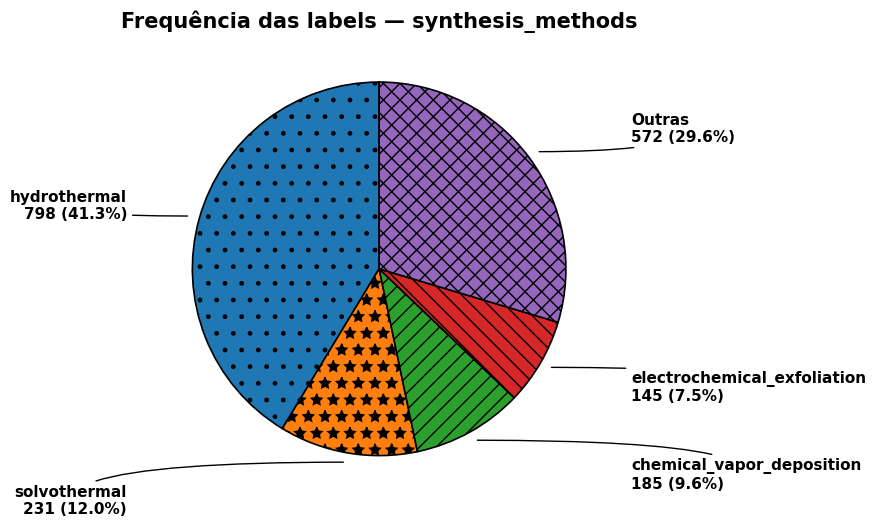

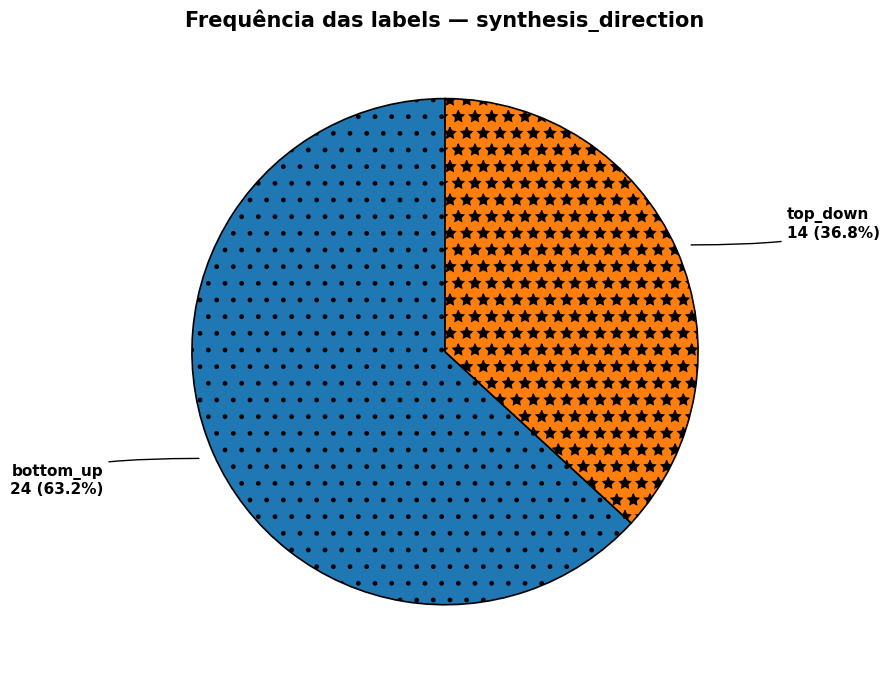

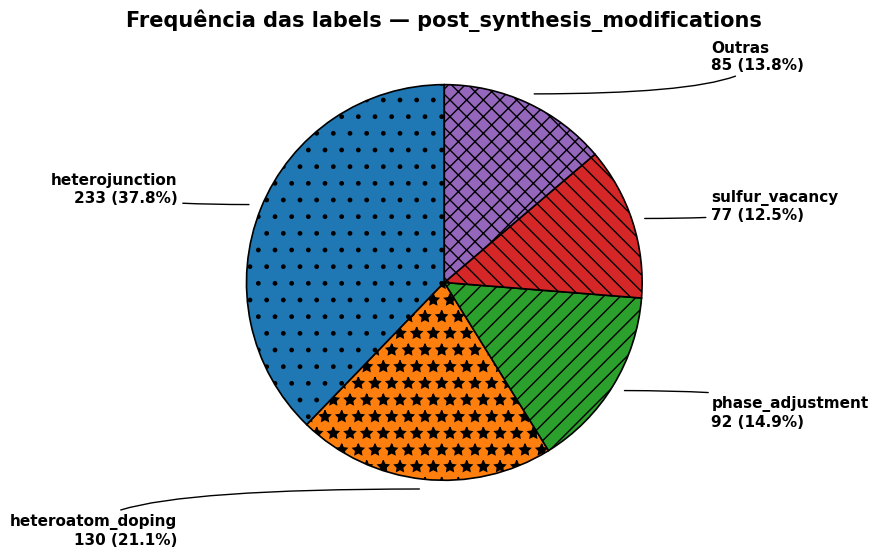

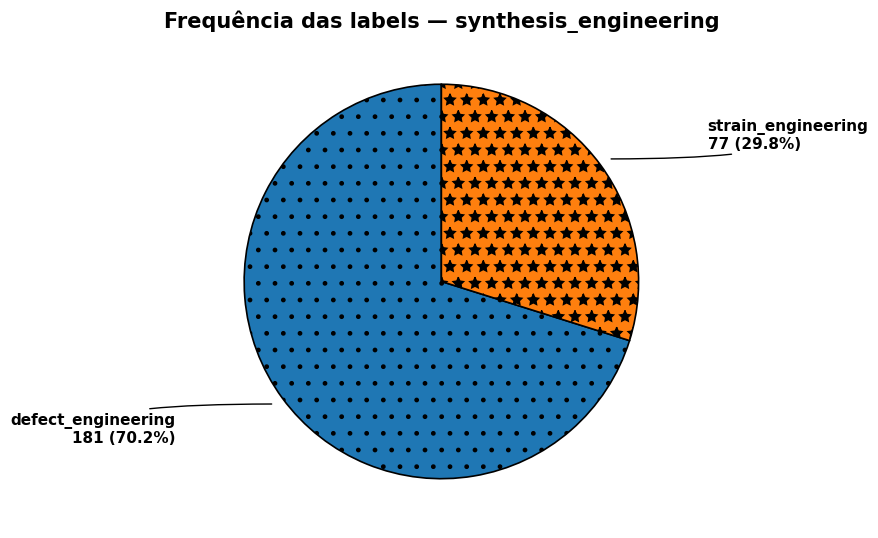

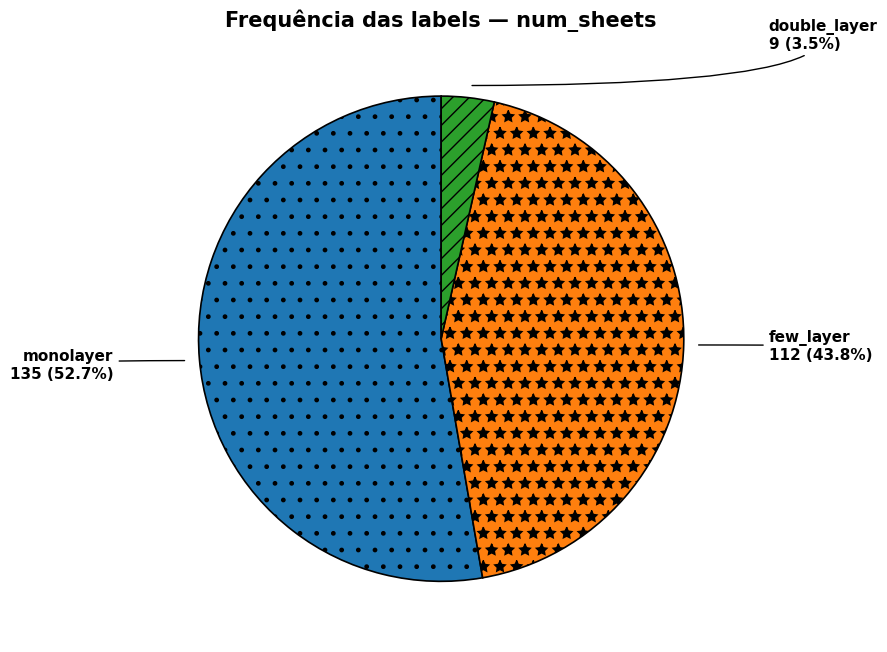

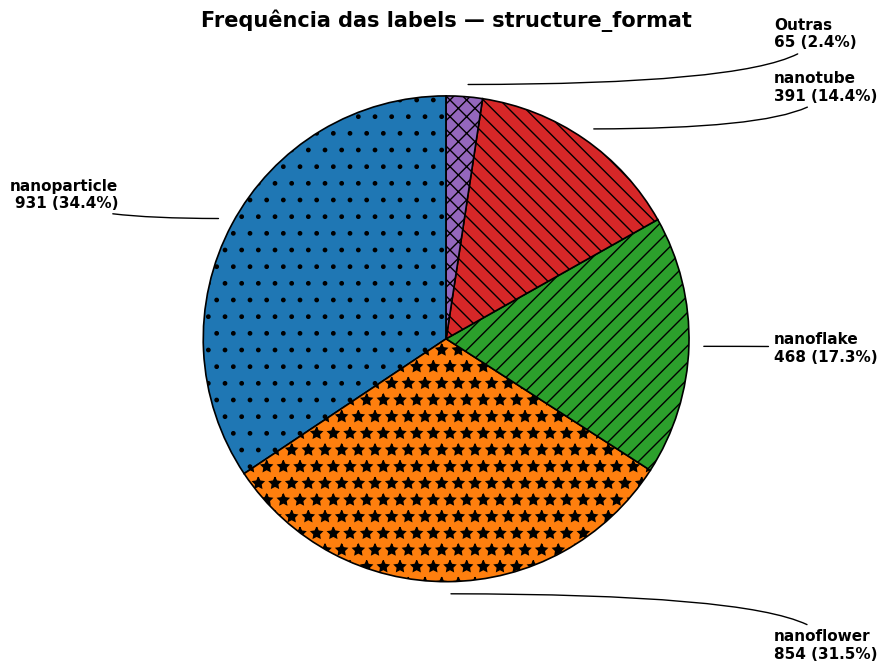

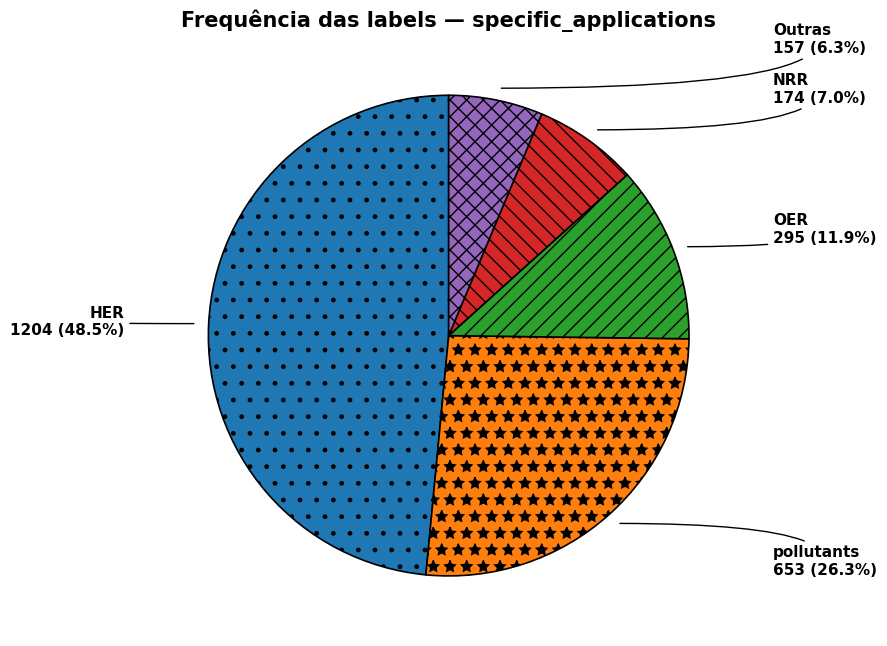

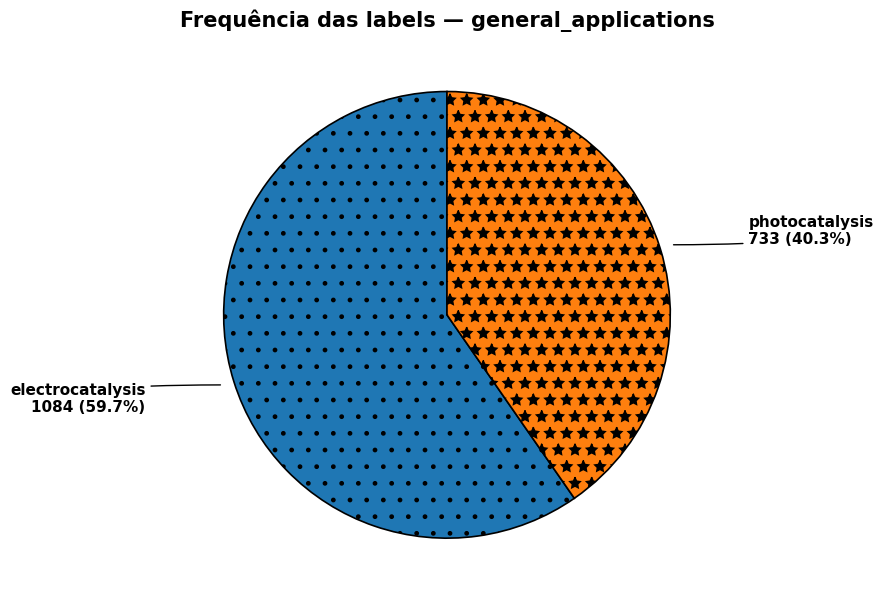

In [251]:
for campo in colunas:
    plot_label_frequency(
        df_extracao, campo, 4
    )